# Team 108 - Part 1: Multi-Armed Bandit
## Adaptive Treatment Recommendation System using Multi-Armed Bandit Learning

**Team Members:**
- ARTHIKA G.
- SRINEVEDA R S.
- ASWATHY H.
- AMIYA PALAI
- KUTAREKAR NISHCHAL AJAY

**Group Number:** 108

## Execution Header: Timestamp and Virtual Machine ID

In [1]:
"""Team 108 - Multi-Armed Bandit assignment solution.

This notebook implements the complete Part 1 requirement for the DRL assignment.
It creates the group-specific synthetic treatment environment, evaluates the
required bandit strategies, saves detailed iteration logs, and generates the
comparison graph used in the final PDF submission.
"""

from __future__ import annotations

import math
import platform
import random
import subprocess
import time
import uuid
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assignment constants for Team 108.
GROUP_NUMBER = 108
TEAM_MEMBERS = [
    "ARTHIKA G .",
    "SRINEVEDA R S .",
    "ASWATHY H .",
    "AMIYA PALAI .",
    "KUTAREKAR NISHCHAL AJAY .",
]
NUM_PATIENTS = 1000

# Output paths
OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
MAB_LOG_PATH = OUTPUT_DIR / "Team_108_MAB_iteration_log.csv"
MAB_SUMMARY_PATH = OUTPUT_DIR / "Team_108_MAB_summary.csv"
MAB_FIGURE_PATH = FIGURE_DIR / "Team_108_MAB_cumulative_reward.png"


def fetch_virtual_machine_id() -> str:
    """Fetches a VM or machine identifier for the assignment execution header.

    The virtual lab can run on different operating systems. The function first
    tries common Windows UUID commands, then Linux machine-id files, and finally
    falls back to a MAC-address-derived identifier.
    """
    commands = [
        ["powershell", "-NoProfile", "-Command", "(Get-CimInstance Win32_ComputerSystemProduct).UUID"],
        ["wmic", "csproduct", "get", "UUID"],
    ]

    for command in commands:
        try:
            completed = subprocess.run(command, capture_output=True, text=True, timeout=5, check=False)
        except (FileNotFoundError, subprocess.SubprocessError, OSError):
            continue

        output_lines = [line.strip() for line in completed.stdout.splitlines() if line.strip()]
        for line in output_lines:
            if line.lower() != "uuid" and len(line) >= 8:
                return line

    for machine_id_path in (Path("/etc/machine-id"), Path("/var/lib/dbus/machine-id")):
        if machine_id_path.exists():
            machine_id = machine_id_path.read_text(encoding="utf-8").strip()
            if machine_id:
                return machine_id

    return f"MAC-{uuid.getnode():012x}"


def print_execution_header(title: str) -> None:
    """Prints the timestamp, VM ID, team members, and group number."""
    print("=" * 90)
    print(title)
    print("=" * 90)
    print(f"Execution timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Virtual Machine ID  : {fetch_virtual_machine_id()}")
    print(f"Machine name        : {platform.node()}")
    print(f"Group number        : {GROUP_NUMBER}")
    print(f"Team members        : {', '.join(TEAM_MEMBERS)}")
    print("=" * 90)


# Print execution header with timestamp and VM ID
print_execution_header("Team 108 - Part 1 MAB: Adaptive Treatment Recommendation System")

Team 108 - Part 1 MAB: Adaptive Treatment Recommendation System
Execution timestamp : 2026-06-04 23:03:01
Virtual Machine ID  : 4C4C4544-0054-5210-804B-B1C04F4B5833
Machine name        : OTX-1TRKKX3
Group number        : 108
Team members        : ARTHIKA G ., SRINEVEDA R S ., ASWATHY H ., AMIYA PALAI ., KUTAREKAR NISHCHAL AJAY .


## Helper Functions and Data Structures

In [2]:
@dataclass
class BanditResult:
    """Stores all outputs from one bandit strategy simulation."""
    strategy_name: str
    patient_trace: pd.DataFrame
    cumulative_rewards: np.ndarray
    assignment_counts: np.ndarray
    recovery_counts: np.ndarray
    estimated_best_history: List[int]
    final_reward: float
    final_best_medicine: int
    convergence_patient: Optional[int]
    stability_score: float


def set_reproducibility(group_number: int) -> None:
    """Sets Python and NumPy random seeds using the required group number."""
    random.seed(group_number)
    np.random.seed(group_number)


def calculate_number_of_medicines(group_number: int) -> int:
    """Calculates K using the assignment formula K = (G mod 3) + 5."""
    return (group_number % 3) + 5


def calculate_hidden_success_probabilities(group_number: int, number_of_medicines: int) -> np.ndarray:
    """Calculates the hidden success probability for each medicine arm."""
    probabilities = []
    for medicine_index in range(number_of_medicines):
        probability = 0.4 + (((group_number + medicine_index) % 6) * 0.07)
        probabilities.append(round(probability, 4))
    return np.array(probabilities, dtype=float)


def create_patient_dataset(num_patients: int) -> pd.DataFrame:
    """Creates the base patient dataset with patient_id and severity_score."""
    patient_ids = np.arange(num_patients)
    severity_scores = (patient_ids % 5) + 1
    return pd.DataFrame({"patient_id": patient_ids, "severity_score": severity_scores})


def sample_clinical_outcome(rng: np.random.RandomState, success_probability: float) -> int:
    """Samples binary recovery outcome using the medicine success probability."""
    return int(rng.binomial(1, success_probability))


def calculate_utility_score(clinical_outcome: int, severity_score: int) -> float:
    """Calculates hospital utility score using the assignment reward formula."""
    return float(clinical_outcome * (1 - (severity_score / 10)))


def estimate_recovery_rates(recovery_counts: np.ndarray, assignment_counts: np.ndarray) -> np.ndarray:
    """Computes observed recovery rate for each medicine with safe zero handling."""
    rates = np.divide(
        recovery_counts,
        assignment_counts,
        out=np.zeros_like(recovery_counts, dtype=float),
        where=assignment_counts > 0,
    )
    return rates


def choose_best_observed_medicine(recovery_counts: np.ndarray, assignment_counts: np.ndarray) -> int:
    """Chooses the medicine with the highest observed recovery rate."""
    rates = estimate_recovery_rates(recovery_counts, assignment_counts)
    return int(np.argmax(rates))


def find_stable_convergence_patient(estimated_best_history: Sequence[int], true_best_medicine: int) -> Optional[int]:
    """Finds the first patient after which the estimated best arm stays correct."""
    for index in range(len(estimated_best_history)):
        remaining_history = estimated_best_history[index:]
        if remaining_history and all(best == true_best_medicine for best in remaining_history):
            return index + 1
    return None


def calculate_stability_score(cumulative_rewards: np.ndarray, window_size: int = 50) -> float:
    """Measures reward-curve stability using rolling reward variation."""
    reward_increments = np.diff(np.insert(cumulative_rewards, 0, 0.0))
    if len(reward_increments) < window_size:
        return float(np.std(reward_increments))

    rolling_totals = []
    for start_index in range(0, len(reward_increments) - window_size + 1):
        rolling_totals.append(float(np.sum(reward_increments[start_index : start_index + window_size])))
    return float(np.std(rolling_totals))


def build_trace_dataframe(base_patients: pd.DataFrame, records: List[Dict[str, float]]) -> pd.DataFrame:
    """Combines base patient data with algorithm decisions and rewards."""
    trace = base_patients.copy()
    trace["assigned_medicine"] = [record["assigned_medicine"] for record in records]
    trace["clinical_outcome"] = [record["clinical_outcome"] for record in records]
    trace["utility_score"] = [record["utility_score"] for record in records]
    trace["cumulative_reward"] = [record["cumulative_reward"] for record in records]
    trace["estimated_best_medicine"] = [record["estimated_best_medicine"] for record in records]
    return trace


def make_bandit_result(
    strategy_name: str,
    base_patients: pd.DataFrame,
    records: List[Dict[str, float]],
    assignment_counts: np.ndarray,
    recovery_counts: np.ndarray,
    estimated_best_history: List[int],
    true_best_medicine: int,
) -> BanditResult:
    """Creates a BanditResult object from raw simulation outputs."""
    trace = build_trace_dataframe(base_patients, records)
    cumulative_rewards = trace["cumulative_reward"].to_numpy(dtype=float)
    final_reward = float(cumulative_rewards[-1])
    final_best_medicine = choose_best_observed_medicine(recovery_counts, assignment_counts)
    convergence_patient = find_stable_convergence_patient(estimated_best_history, true_best_medicine)
    stability_score = calculate_stability_score(cumulative_rewards)

    return BanditResult(
        strategy_name=strategy_name,
        patient_trace=trace,
        cumulative_rewards=cumulative_rewards,
        assignment_counts=assignment_counts.copy(),
        recovery_counts=recovery_counts.copy(),
        estimated_best_history=list(estimated_best_history),
        final_reward=final_reward,
        final_best_medicine=final_best_medicine,
        convergence_patient=convergence_patient,
        stability_score=stability_score,
    )


print("Helper functions loaded successfully.")

Helper functions loaded successfully.


## Task 1: Dataset Design (1 Mark)

**Objective:** Generate the synthetic patient-treatment dataset based on group number.

**Requirements:**
1. Calculate number of medicines K = (G mod 3) + 5
2. Calculate hidden success probabilities: P_i = 0.4 + ((G + i) mod 6) × 0.07
3. Generate 1000 patient records with severity scores
4. Display group number, total medicines, hidden probabilities
5. Print first 10 dataset rows

In [3]:
# Set reproducibility using group number
set_reproducibility(GROUP_NUMBER)

# Calculate number of medicines K
number_of_medicines = calculate_number_of_medicines(GROUP_NUMBER)

# Calculate hidden success probabilities
success_probabilities = calculate_hidden_success_probabilities(GROUP_NUMBER, number_of_medicines)

# Create patient dataset
base_patients = create_patient_dataset(NUM_PATIENTS)

# Identify true best medicine
true_best_medicine = int(np.argmax(success_probabilities))

# Print Task 1 results
print("\nTASK 1: Dataset Design")
print("-" * 90)
print(f"Group number G                 : {GROUP_NUMBER}")
print(f"Total medicines K              : {number_of_medicines}")
print("Hidden success probabilities Pi :")
for medicine_index, probability in enumerate(success_probabilities):
    print(f"  Medicine {medicine_index}: {probability:.2f}")
print(f"\nTrue best medicine based on hidden probability: Medicine {true_best_medicine}")
print("\nFirst 10 patient records before algorithm assignment:")
print(base_patients.head(10).to_string(index=False))


TASK 1: Dataset Design
------------------------------------------------------------------------------------------
Group number G                 : 108
Total medicines K              : 5
Hidden success probabilities Pi :
  Medicine 0: 0.40
  Medicine 1: 0.47
  Medicine 2: 0.54
  Medicine 3: 0.61
  Medicine 4: 0.68

True best medicine based on hidden probability: Medicine 4

First 10 patient records before algorithm assignment:
 patient_id  severity_score
          0               1
          1               2
          2               3
          3               4
          4               5
          5               1
          6               2
          7               3
          8               4
          9               5


## Task 2: Immediate Exploitation Strategy (1 Mark)

**Objective:** Implement the greedy exploitation strategy.

**Strategy:** Test each medicine exactly 10 times initially, then continue using only the currently best-performing medicine for all remaining patients.

**Requirements:**
1. Test each medicine 10 times in initialization phase
2. Exploit best observed medicine for remaining patients
3. Track cumulative reward
4. Display first 10 and last 5 iteration rows

In [4]:
def simulate_immediate_exploitation(
    base_patients: pd.DataFrame,
    success_probabilities: np.ndarray,
    group_number: int,
) -> BanditResult:
    """Runs the initial-test-then-exploit strategy required in Task 2.

    Each medicine is tested exactly ten times. After this initialization phase,
    all remaining patients receive the medicine with the best observed recovery
    rate. Clinical outcomes update bandit statistics and utility updates reward.
    """
    rng = np.random.RandomState(group_number + 11)
    number_of_medicines = len(success_probabilities)
    assignment_counts = np.zeros(number_of_medicines, dtype=int)
    recovery_counts = np.zeros(number_of_medicines, dtype=int)
    estimated_best_history: List[int] = []
    records: List[Dict[str, float]] = []
    cumulative_reward = 0.0
    initialization_patients = number_of_medicines * 10

    for row_index, patient in base_patients.iterrows():
        if row_index < initialization_patients:
            assigned_medicine = row_index // 10
        else:
            assigned_medicine = choose_best_observed_medicine(recovery_counts, assignment_counts)

        clinical_outcome = sample_clinical_outcome(rng, success_probabilities[assigned_medicine])
        utility_score = calculate_utility_score(clinical_outcome, int(patient["severity_score"]))

        assignment_counts[assigned_medicine] += 1
        recovery_counts[assigned_medicine] += clinical_outcome
        cumulative_reward += utility_score

        estimated_best_medicine = choose_best_observed_medicine(recovery_counts, assignment_counts)
        estimated_best_history.append(estimated_best_medicine)

        records.append(
            {
                "assigned_medicine": assigned_medicine,
                "clinical_outcome": clinical_outcome,
                "utility_score": utility_score,
                "cumulative_reward": cumulative_reward,
                "estimated_best_medicine": estimated_best_medicine,
            }
        )

    true_best_medicine = int(np.argmax(success_probabilities))
    return make_bandit_result(
        "Immediate Exploitation",
        base_patients,
        records,
        assignment_counts,
        recovery_counts,
        estimated_best_history,
        true_best_medicine,
    )


# Execute Task 2
immediate_result = simulate_immediate_exploitation(base_patients, success_probabilities, GROUP_NUMBER)

# Print results
print("\nTASK 2: Immediate Exploitation Strategy")
print("-" * 90)
recovery_rates = estimate_recovery_rates(immediate_result.recovery_counts, immediate_result.assignment_counts)
print(f"Final cumulative utility reward : {immediate_result.final_reward:.3f}")
print(f"Final best observed medicine    : {immediate_result.final_best_medicine}")
print(f"Convergence patient             : {immediate_result.convergence_patient if immediate_result.convergence_patient else 'Not stable'}")
print(f"Stability score                 : {immediate_result.stability_score:.3f}")
print(f"Medicine selection counts       : {immediate_result.assignment_counts.tolist()}")
print(f"Observed recovery rates         : {np.round(recovery_rates, 3).tolist()}")
print("\nFirst 10 algorithm iteration rows:")
print(immediate_result.patient_trace.head(10).to_string(index=False))
print("\nLast 5 algorithm iteration rows:")
print(immediate_result.patient_trace.tail(5).to_string(index=False))


TASK 2: Immediate Exploitation Strategy
------------------------------------------------------------------------------------------
Final cumulative utility reward : 466.700
Final best observed medicine    : 4
Convergence patient             : 43
Stability score                 : 2.436
Medicine selection counts       : [10, 10, 10, 10, 960]
Observed recovery rates         : [0.4, 0.5, 0.3, 0.6, 0.676]

First 10 algorithm iteration rows:
 patient_id  severity_score  assigned_medicine  clinical_outcome  utility_score  cumulative_reward  estimated_best_medicine
          0               1                  0                 1            0.9                0.9                        0
          1               2                  0                 0            0.0                0.9                        0
          2               3                  0                 0            0.0                0.9                        0
          3               4                  0                 

## Task 3: Controlled Clinical Trial Strategy (Epsilon-Greedy) (1.5 Marks)

**Objective:** Implement epsilon-greedy exploration strategy.

**Strategy:** Most patients receive the current best treatment, but with ε probability, test another treatment to discover hidden opportunities.

**Requirements:**
1. Implement with 10% exploration
2. Run for 1000 patients
3. Analyze with 1% and 50% exploration rates
4. Compare performance across exploration rates

In [5]:
def simulate_epsilon_greedy(
    base_patients: pd.DataFrame,
    success_probabilities: np.ndarray,
    group_number: int,
    epsilon: float,
    seed_offset: int,
) -> BanditResult:
    """Runs controlled exploration using epsilon-greedy treatment assignment."""
    rng = np.random.RandomState(group_number + seed_offset)
    number_of_medicines = len(success_probabilities)
    assignment_counts = np.zeros(number_of_medicines, dtype=int)
    recovery_counts = np.zeros(number_of_medicines, dtype=int)
    estimated_best_history: List[int] = []
    records: List[Dict[str, float]] = []
    cumulative_reward = 0.0

    for _, patient in base_patients.iterrows():
        if np.any(assignment_counts == 0):
            assigned_medicine = int(np.argmin(assignment_counts))
        elif rng.random_sample() < epsilon:
            assigned_medicine = int(rng.randint(0, number_of_medicines))
        else:
            assigned_medicine = choose_best_observed_medicine(recovery_counts, assignment_counts)

        clinical_outcome = sample_clinical_outcome(rng, success_probabilities[assigned_medicine])
        utility_score = calculate_utility_score(clinical_outcome, int(patient["severity_score"]))

        assignment_counts[assigned_medicine] += 1
        recovery_counts[assigned_medicine] += clinical_outcome
        cumulative_reward += utility_score

        estimated_best_medicine = choose_best_observed_medicine(recovery_counts, assignment_counts)
        estimated_best_history.append(estimated_best_medicine)

        records.append(
            {
                "assigned_medicine": assigned_medicine,
                "clinical_outcome": clinical_outcome,
                "utility_score": utility_score,
                "cumulative_reward": cumulative_reward,
                "estimated_best_medicine": estimated_best_medicine,
            }
        )

    true_best_medicine = int(np.argmax(success_probabilities))
    return make_bandit_result(
        f"Epsilon-Greedy {epsilon:.0%}",
        base_patients,
        records,
        assignment_counts,
        recovery_counts,
        estimated_best_history,
        true_best_medicine,
    )


# Execute Task 3 with different exploration rates
epsilon_10_result = simulate_epsilon_greedy(base_patients, success_probabilities, GROUP_NUMBER, epsilon=0.10, seed_offset=21)
epsilon_01_result = simulate_epsilon_greedy(base_patients, success_probabilities, GROUP_NUMBER, epsilon=0.01, seed_offset=22)
epsilon_50_result = simulate_epsilon_greedy(base_patients, success_probabilities, GROUP_NUMBER, epsilon=0.50, seed_offset=23)

# Print results for each epsilon value
print("\nTASK 3: Controlled Clinical Trial Strategy (Epsilon-Greedy)")
print("=" * 90)

for result in [epsilon_01_result, epsilon_10_result, epsilon_50_result]:
    recovery_rates = estimate_recovery_rates(result.recovery_counts, result.assignment_counts)
    print(f"\n{result.strategy_name}")
    print("-" * 90)
    print(f"Final cumulative utility reward : {result.final_reward:.3f}")
    print(f"Final best observed medicine    : {result.final_best_medicine}")
    print(f"Convergence patient             : {result.convergence_patient if result.convergence_patient else 'Not stable'}")
    print(f"Stability score                 : {result.stability_score:.3f}")
    print(f"Medicine selection counts       : {result.assignment_counts.tolist()}")
    print(f"Observed recovery rates         : {np.round(recovery_rates, 3).tolist()}")
    print("First 10 algorithm iteration rows:")
    print(result.patient_trace.head(10).to_string(index=False))
    print("Last 5 algorithm iteration rows:")
    print(result.patient_trace.tail(5).to_string(index=False))


TASK 3: Controlled Clinical Trial Strategy (Epsilon-Greedy)

Epsilon-Greedy 1%
------------------------------------------------------------------------------------------
Final cumulative utility reward : 480.500
Final best observed medicine    : 4
Convergence patient             : 14
Stability score                 : 2.383
Medicine selection counts       : [2, 1, 5, 12, 980]
Observed recovery rates         : [0.0, 0.0, 0.2, 0.5, 0.694]
First 10 algorithm iteration rows:
 patient_id  severity_score  assigned_medicine  clinical_outcome  utility_score  cumulative_reward  estimated_best_medicine
          0               1                  0                 0            0.0                0.0                        0
          1               2                  1                 0            0.0                0.0                        0
          2               3                  2                 0            0.0                0.0                        0
          3               4 

## Task 4: Confidence-Based Strategy (UCB1) (1 Mark)

**Objective:** Implement the Upper Confidence Bound (UCB1) algorithm.

**Strategy:** Treatments with fewer observations are given more chances initially, but this preference reduces as evidence grows.

**Requirements:**
1. Implement UCB1 algorithm
2. Balance exploration and exploitation using confidence bounds
3. Evaluate cumulative reward over 1000 patients

In [6]:
def simulate_ucb1(
    base_patients: pd.DataFrame,
    success_probabilities: np.ndarray,
    group_number: int,
) -> BanditResult:
    """Runs the UCB1 confidence-based strategy required in Task 4."""
    rng = np.random.RandomState(group_number + 41)
    number_of_medicines = len(success_probabilities)
    assignment_counts = np.zeros(number_of_medicines, dtype=int)
    recovery_counts = np.zeros(number_of_medicines, dtype=int)
    estimated_best_history: List[int] = []
    records: List[Dict[str, float]] = []
    cumulative_reward = 0.0

    for patient_index, patient in base_patients.iterrows():
        if patient_index < number_of_medicines:
            assigned_medicine = patient_index
        else:
            recovery_rates = estimate_recovery_rates(recovery_counts, assignment_counts)
            confidence_bonus = np.sqrt((2 * np.log(patient_index + 1)) / assignment_counts)
            ucb_scores = recovery_rates + confidence_bonus
            assigned_medicine = int(np.argmax(ucb_scores))

        clinical_outcome = sample_clinical_outcome(rng, success_probabilities[assigned_medicine])
        utility_score = calculate_utility_score(clinical_outcome, int(patient["severity_score"]))

        assignment_counts[assigned_medicine] += 1
        recovery_counts[assigned_medicine] += clinical_outcome
        cumulative_reward += utility_score

        estimated_best_medicine = choose_best_observed_medicine(recovery_counts, assignment_counts)
        estimated_best_history.append(estimated_best_medicine)

        records.append(
            {
                "assigned_medicine": assigned_medicine,
                "clinical_outcome": clinical_outcome,
                "utility_score": utility_score,
                "cumulative_reward": cumulative_reward,
                "estimated_best_medicine": estimated_best_medicine,
            }
        )

    true_best_medicine = int(np.argmax(success_probabilities))
    return make_bandit_result(
        "UCB1 Confidence-Based",
        base_patients,
        records,
        assignment_counts,
        recovery_counts,
        estimated_best_history,
        true_best_medicine,
    )


# Execute Task 4
ucb1_result = simulate_ucb1(base_patients, success_probabilities, GROUP_NUMBER)

# Print results
print("\nTASK 4: Confidence-Based Strategy (UCB1)")
print("-" * 90)
recovery_rates = estimate_recovery_rates(ucb1_result.recovery_counts, ucb1_result.assignment_counts)
print(f"Final cumulative utility reward : {ucb1_result.final_reward:.3f}")
print(f"Final best observed medicine    : {ucb1_result.final_best_medicine}")
print(f"Convergence patient             : {ucb1_result.convergence_patient if ucb1_result.convergence_patient else 'Not stable'}")
print(f"Stability score                 : {ucb1_result.stability_score:.3f}")
print(f"Medicine selection counts       : {ucb1_result.assignment_counts.tolist()}")
print(f"Observed recovery rates         : {np.round(recovery_rates, 3).tolist()}")
print("\nFirst 10 algorithm iteration rows:")
print(ucb1_result.patient_trace.head(10).to_string(index=False))
print("\nLast 5 algorithm iteration rows:")
print(ucb1_result.patient_trace.tail(5).to_string(index=False))


TASK 4: Confidence-Based Strategy (UCB1)
------------------------------------------------------------------------------------------
Final cumulative utility reward : 431.200
Final best observed medicine    : 4
Convergence patient             : 109
Stability score                 : 2.973
Medicine selection counts       : [84, 83, 101, 290, 442]
Observed recovery rates         : [0.452, 0.446, 0.485, 0.645, 0.681]

First 10 algorithm iteration rows:
 patient_id  severity_score  assigned_medicine  clinical_outcome  utility_score  cumulative_reward  estimated_best_medicine
          0               1                  0                 1            0.9                0.9                        0
          1               2                  1                 1            0.8                1.7                        0
          2               3                  2                 0            0.0                1.7                        0
          3               4                  3     

## Task 5: Comparative Analysis (0.5 Marks)

**Objective:** Compare all implemented strategies and provide comprehensive analysis.

**Requirements:**
1. Generate Cumulative Reward vs. Number of Patients graph
2. Answer the following questions:
   - Which strategy achieves the highest cumulative reward?
   - Which strategy identifies the best medicine fastest?
   - Which strategy shows the most stable performance?
   - Which strategy is safest for real-world deployment?
3. Write a 3-5 sentence comparative summary

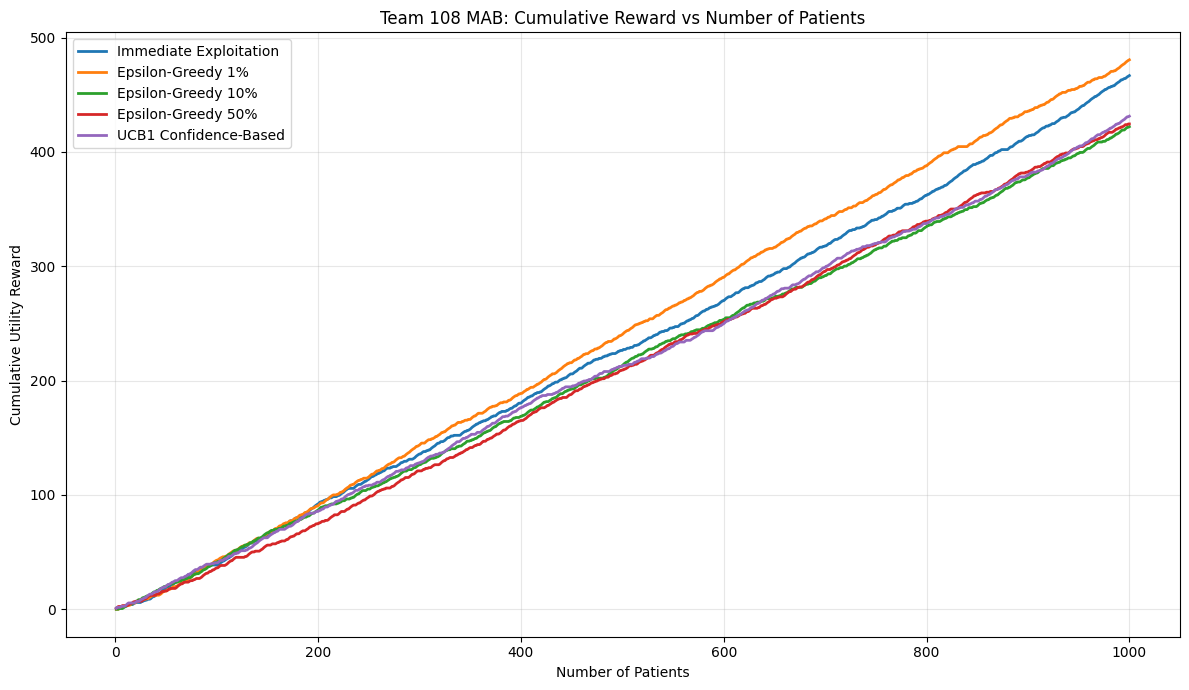


TASK 5: Comparative Analysis Answers
------------------------------------------------------------------------------------------
Full comparison table:
              strategy  final_cumulative_reward  final_best_medicine  true_best_medicine_selected_count  convergence_patient  stability_score_lower_is_better             observed_recovery_rates medicine_selection_counts
Immediate Exploitation                    466.7                    4                                960                   43                            2.436         [0.4, 0.5, 0.3, 0.6, 0.676]     [10, 10, 10, 10, 960]
     Epsilon-Greedy 1%                    480.5                    4                                980                   14                            2.383         [0.0, 0.0, 0.2, 0.5, 0.694]        [2, 1, 5, 12, 980]
    Epsilon-Greedy 10%                    422.0                    4                                179                  849                            2.166   [0.278, 0.393, 0.409, 0.61, 

In [7]:
# Collect all results
results = [immediate_result, epsilon_01_result, epsilon_10_result, epsilon_50_result, ucb1_result]

# Create summary table
def create_summary_table(results: Iterable[BanditResult], success_probabilities: np.ndarray) -> pd.DataFrame:
    """Creates a compact comparison table for all implemented strategies."""
    true_best_medicine = int(np.argmax(success_probabilities))
    summary_rows = []
    for result in results:
        recovery_rates = estimate_recovery_rates(result.recovery_counts, result.assignment_counts)
        summary_rows.append(
            {
                "strategy": result.strategy_name,
                "final_cumulative_reward": round(result.final_reward, 3),
                "final_best_medicine": result.final_best_medicine,
                "true_best_medicine_selected_count": int(result.assignment_counts[true_best_medicine]),
                "convergence_patient": result.convergence_patient if result.convergence_patient else "Not stable",
                "stability_score_lower_is_better": round(result.stability_score, 3),
                "observed_recovery_rates": np.round(recovery_rates, 3).tolist(),
                "medicine_selection_counts": result.assignment_counts.tolist(),
            }
        )
    return pd.DataFrame(summary_rows)


summary_table = create_summary_table(results, success_probabilities)

# Plot cumulative rewards
def plot_cumulative_rewards(results: Sequence[BanditResult], output_path: Path) -> None:
    """Plots cumulative reward against patient count for every strategy."""
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(12, 7))
    patient_axis = np.arange(1, NUM_PATIENTS + 1)

    for result in results:
        plt.plot(patient_axis, result.cumulative_rewards, linewidth=2, label=result.strategy_name)

    plt.title("Team 108 MAB: Cumulative Reward vs Number of Patients")
    plt.xlabel("Number of Patients")
    plt.ylabel("Cumulative Utility Reward")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=180)
    plt.show()


# Generate plot
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
plot_cumulative_rewards(results, MAB_FIGURE_PATH)

# Save summary and iteration logs
summary_table.to_csv(MAB_SUMMARY_PATH, index=False)

def save_iteration_logs(results: Sequence[BanditResult], output_path: Path) -> None:
    """Saves full per-patient iteration records for all strategies."""
    output_path.parent.mkdir(parents=True, exist_ok=True)
    combined_frames = []
    for result in results:
        strategy_trace = result.patient_trace.copy()
        strategy_trace.insert(0, "strategy", result.strategy_name)
        combined_frames.append(strategy_trace)
    pd.concat(combined_frames, ignore_index=True).to_csv(output_path, index=False)


save_iteration_logs(results, MAB_LOG_PATH)

# Print comparative analysis
print("\nTASK 5: Comparative Analysis Answers")
print("-" * 90)
print("Full comparison table:")
print(summary_table.to_string(index=False))

# Answer Question 1
highest_reward_row = summary_table.sort_values("final_cumulative_reward", ascending=False).iloc[0]
print(f"\n1. Highest final cumulative reward: {highest_reward_row['strategy']} with {highest_reward_row['final_cumulative_reward']}.")

# Answer Question 2
convergence_candidates = summary_table[summary_table["convergence_patient"] != "Not stable"].copy()
if convergence_candidates.empty:
    fastest_strategy = "No strategy showed stable convergence to the true best medicine."
else:
    convergence_candidates["convergence_patient"] = convergence_candidates["convergence_patient"].astype(int)
    fastest_row = convergence_candidates.sort_values("convergence_patient", ascending=True).iloc[0]
    fastest_strategy = f"{fastest_row['strategy']} at patient {fastest_row['convergence_patient']}"
print(f"2. Fastest stable identification of best medicine: {fastest_strategy}.")

# Answer Question 3
most_stable_row = summary_table.sort_values("stability_score_lower_is_better", ascending=True).iloc[0]
print(f"3. Most stable cumulative performance: {most_stable_row['strategy']} based on the lowest rolling reward variation.")

# Answer Question 4
print(
    "4. Safest real-world recommendation: UCB1, because it gives less-tested medicines "
    "a mathematically controlled opportunity early and naturally reduces that exploration "
    "as clinical evidence grows."
)

# Comparative Summary
ucb_row = summary_table[summary_table["strategy"] == "UCB1 Confidence-Based"].iloc[0]
print("\nShort comparative summary (3-5 sentences):")
print(
    "The immediate exploitation strategy can earn high reward if the initial ten trials per medicine "
    "correctly identify the strongest medicine, but it is risky because early random outcomes can lock "
    "the hospital into a suboptimal treatment. Epsilon-greedy with 10% exploration provides a practical "
    "balance, while 1% may under-explore and 50% may sacrifice too much reward through excessive testing. "
    f"In this run, UCB1 selected the true best medicine {ucb_row['true_best_medicine_selected_count']} times "
    "and remains the safest deployment choice because its exploration is evidence-driven rather than fixed."
)

print("\nSaved assignment artifacts:")
print(f"- Full iteration log : {MAB_LOG_PATH}")
print(f"- Summary table      : {MAB_SUMMARY_PATH}")
print(f"- Reward plot        : {MAB_FIGURE_PATH}")

## Summary

This notebook has successfully implemented and evaluated all required Multi-Armed Bandit strategies for Team 108:

1. **Task 1:** Created group-specific synthetic dataset with proper formulas
2. **Task 2:** Implemented immediate exploitation strategy
3. **Task 3:** Implemented epsilon-greedy with 1%, 10%, and 50% exploration
4. **Task 4:** Implemented UCB1 confidence-based strategy
5. **Task 5:** Performed comprehensive comparative analysis with visualization

All outputs, iteration logs, and figures have been saved to the outputs directory for inclusion in the final PDF submission.